# 🗺️ Plan Universel — Machine Learning Project

## 1.  Importation des bibliothèques
## 2.  Chargement du dataset
## 3.  Analyse exploratoire (EDA) + Visualisation
## 4.  Préparation & Preprocessing
   - Nettoyage des données
   - Encodage (si nécessaire)
   - Normalisation
   - Train/Test Split
## 5.  Entraînement du modèle
## 6.  Évaluation & Test
   - Métriques (MAE, RMSE, R² ou Accuracy...)
   - Validation croisée
   - Visualisation des résultats
## 7.  Enregistrement
   - Sauvegarder le modèle
   - Sauvegarder le scaler

# **MODEL JOUR 1** : Prédire le poids d'un patients en fonction de certaines feature

---



FEATURES : age , taille_cm , graisse_corporelle , tension_diastolic , tension_systolic , force_prehension , abdominaux , saut_longeur

TARGET : poids(kg)

**Explication sur les features : **
1. age : Plus on vieillit, plus la composition corporelle change
2. taille : La taille est directement liée au poids
3. graisse_corporelle : Plus de graisse = plus de poids
4. tension_diastolique : Pression artérielle au repos
5. tension_systolique : Pression artérielle à la contraction
6. force_prehension : Indicateur de la masse musculaire
7. abdominaux : Reflète la condition physique générale
8. saut_longueur : Indicateur de la puissance musculaire
9. flexibilité : Mesure la flexibilité du dos et des ischio-jambiers — le patient se penche en avant assis et on mesure jusqu'où il atteint. Indicateur de souplesse musculaire.





# **1- Setup — Importer les bibliothèques nécessaire**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **2- Chargement — Lire le dataset et avoir une première vue**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving bodyPerformance.csv to bodyPerformance (1).csv


In [33]:
df = pd.read_csv('bodyPerformance.csv')
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [35]:
df = df.rename(columns={
    'weight_kg'         : 'poids',
    'height_cm'         : 'taille',
    'body fat_%'        : 'graisse_corporelle',
    'diastolic'         : 'tension_diastolique',
    'systolic'          : 'tension_systolique',
    'gripForce'         : 'force_prehension',
    'sit-ups counts'    : 'abdominaux',
    'broad jump_cm'     : 'saut_longueur',
    'sit and bend forward_cm' : 'flexibilite'
})

In [36]:
df.head()

,age,gender,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [37]:
df = df.drop(columns=["gender", "class"], axis= 1)


In [38]:
df.head()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  13393 non-null  float64
 1   taille               13393 non-null  float64
 2   poids                13393 non-null  float64
 3   graisse_corporelle   13393 non-null  float64
 4   tension_diastolique  13393 non-null  float64
 5   tension_systolique   13393 non-null  float64
 6   force_prehension     13393 non-null  float64
 7   flexibilite          13393 non-null  float64
 8   abdominaux           13393 non-null  float64
 9   saut_longueur        13393 non-null  float64
dtypes: float64(10)
memory usage: 1.0 MB


Resumé : 13393 observations , pas de données manquante

In [40]:
df.shape  #10 colonnes ; 13393 lignes

(13393, 10)

In [41]:
df.describe()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


ANALYSE EXPLORATOIRE DES DONNES
base : 13393 ELEMENTS NON NULL

Analyse des stats et nettoyage des données :
1. La tension que ce soit diastole  ou le systole ne peut pas etre 0 alors je suppose que ce sont des donnéés manquantes et  je vais visionner et supprimer ou carrement remplacer par la mediane car la moyenne est tres sensible aux outliers
2. On voit clairement que l'age minimun dans ce dataset est 21 ans , alors que cette collecte est réaliser sur les personnes normaux un poids de 26kg ce n'est pas raisonnable . (je pense fixer aussi des règles a ce niveau je remets le minimun du poids a au moins 35 )
3. La flexibilité qui a un max de 213 , biologiquement ce n'est pas possible alors je ne garderai un seuil (50)
4. Graisse corporelle : sachant qu'on est avec de 21 a 64 ans la graisse doit etre entre l'intervalle de (3 et 60) ==== 78 c'est deja pour une patiente morbide
5. force prehension ne peut pas etre 0 au moins  1 pareil pour saut en longueur , abdominaux je garde le 0 juste pour dire que c'est quelqu'un qui deteste la salle de gym

In [55]:
colonnes_suspects = ['tension_diastolique', 'tension_systolique', 'abdominaux', 'force_prehension','saut_longueur', 'flexibilite']
for col in colonnes_suspects:
  zeros = (df[col] == 0).sum()
  print(f"{col} : {zeros} zéros")


tension_diastolique : 1 zéros
tension_systolique : 1 zéros
abdominaux : 125 zéros
force_prehension : 3 zéros
saut_longueur : 10 zéros
flexibilite : 12 zéros


VU ces resultats , je vais carrement supprimer les deux lignes ou la tension est egale a zeros et me laisser les autres , je suppose que ces derniers ne pratique aucun activité sportive ou physique c'est pourquoi on leurs as attribué des zeros .

In [56]:
# Supprimer uniquement les lignes où la tension est à 0
df = df[
    (df['tension_diastolique'] != 0) &
    (df['tension_systolique'] != 0)
]



In [59]:
df.shape
colonnes_suspects = ['tension_diastolique', 'tension_systolique', 'abdominaux', 'force_prehension','saut_longueur', 'flexibilite']
for col in colonnes_suspects:
  zeros = (df[col] == 0).sum()
  print(f"{col} : {zeros} zéros")

df.describe()

tension_diastolique : 0 zéros
tension_systolique : 0 zéros
abdominaux : 125 zéros
force_prehension : 3 zéros
saut_longueur : 10 zéros
flexibilite : 12 zéros


,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000
mean,36.775911,168.560447,67.447606,23.239511,78.802726,130.244542,36.964868,15.209127,39.772476,190.134267
std,13.625830,8.426572,11.950065,7.256720,10.720830,14.671397,10.624642,8.456977,14.276496,39.865873
min,21.000000,125.000000,26.300000,3.000000,6.000000,14.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


AVec mon expérience clinique , je ne crois pas qu'un patient peut avoir une Pression artérielle diastolique == 6 mmhg et une systole egale a = 14mmhg . Pour cela je vais fixer un seuil PAS >= 70 et PAD >= 40

In [62]:
df = df[
    (df['tension_diastolique'] >= 40) &
    (df['tension_systolique'] >= 70)
]
df.shape
df.describe()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000
mean,36.778649,168.560100,67.447031,23.239506,78.823540,130.263783,36.962887,15.210117,39.768415,190.129098
std,13.627318,8.427206,11.950363,7.257401,10.668573,14.613051,10.624634,8.456848,14.276823,39.870770
min,21.000000,125.000000,26.300000,3.000000,40.000000,82.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [64]:
df = df[
    (df['age'] >= 21) &
    (df['poids'] >= 35)
]
df.shape
df.describe()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13381.000000,13381.000000,13381.000000,13381.000000,13381.000000,13381.000000,13381.000000,13381.000000,13381.000000,13381.000000
mean,36.776624,168.566228,67.460217,23.236330,78.825192,130.266423,36.970997,15.208918,39.774681,190.159936
std,13.625778,8.418220,11.932960,7.255168,10.669190,14.614174,10.616392,8.456603,14.272260,39.829544
min,21.000000,139.500000,35.900000,3.000000,40.000000,82.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.440000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [70]:
df = df[
    (df['flexibilite'] >= -25) &
    (df['flexibilite'] <= 50)
]


df.describe()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13367.000000,13367.000000,13367.000000,13367.000000,13367.000000,13367.000000,13367.000000,13367.000000,13367.000000,13367.000000
mean,36.779158,168.565415,67.457145,23.234632,78.824336,130.269844,36.970802,15.195072,39.779158,190.162946
std,13.627585,8.417706,11.931488,7.254938,10.671802,14.616878,10.616879,8.142319,14.271296,39.816309
min,21.000000,139.500000,35.900000,3.000000,40.000000,82.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.440000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,42.000000,80.000000,303.000000


In [71]:
df = df[
    (df['graisse_corporelle'] >= 3) &
    (df['graisse_corporelle'] <= 60)
]

df.describe()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13366.000000,13366.000000,13366.000000,13366.000000,13366.000000,13366.000000,13366.000000,13366.000000,13366.000000,13366.000000
mean,36.780338,168.564739,67.456618,23.230505,78.825071,130.270462,36.970209,15.194256,39.777720,190.159592
std,13.627411,8.417658,11.931779,7.239499,10.671863,14.617250,10.617055,8.142077,14.270861,39.815910
min,21.000000,139.500000,35.900000,3.000000,40.000000,82.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.440000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,54.900000,156.200000,201.000000,70.500000,42.000000,80.000000,303.000000


In [73]:
df = df[
    (df['force_prehension'] > 0) &
    (df['saut_longueur'] > 0)
]

df.describe()

,age,taille,poids,graisse_corporelle,tension_diastolique,tension_systolique,force_prehension,flexibilite,abdominaux,saut_longueur
count,13354.000000,13354.000000,13354.000000,13354.000000,13354.000000,13354.000000,13354.000000,13354.000000,13354.000000,13354.000000
mean,36.772353,168.567178,67.455396,23.224886,78.826636,130.269807,36.983556,15.195449,39.790849,190.282619
std,13.623007,8.417878,11.931724,7.233836,10.670029,14.617182,10.601116,8.141504,14.254532,39.520645
min,21.000000,139.500000,35.900000,3.000000,40.000000,82.000000,1.600000,-25.000000,0.000000,20.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.450000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.775000,50.000000,221.000000
max,64.000000,193.800000,138.100000,54.900000,156.200000,201.000000,70.500000,42.000000,80.000000,303.000000


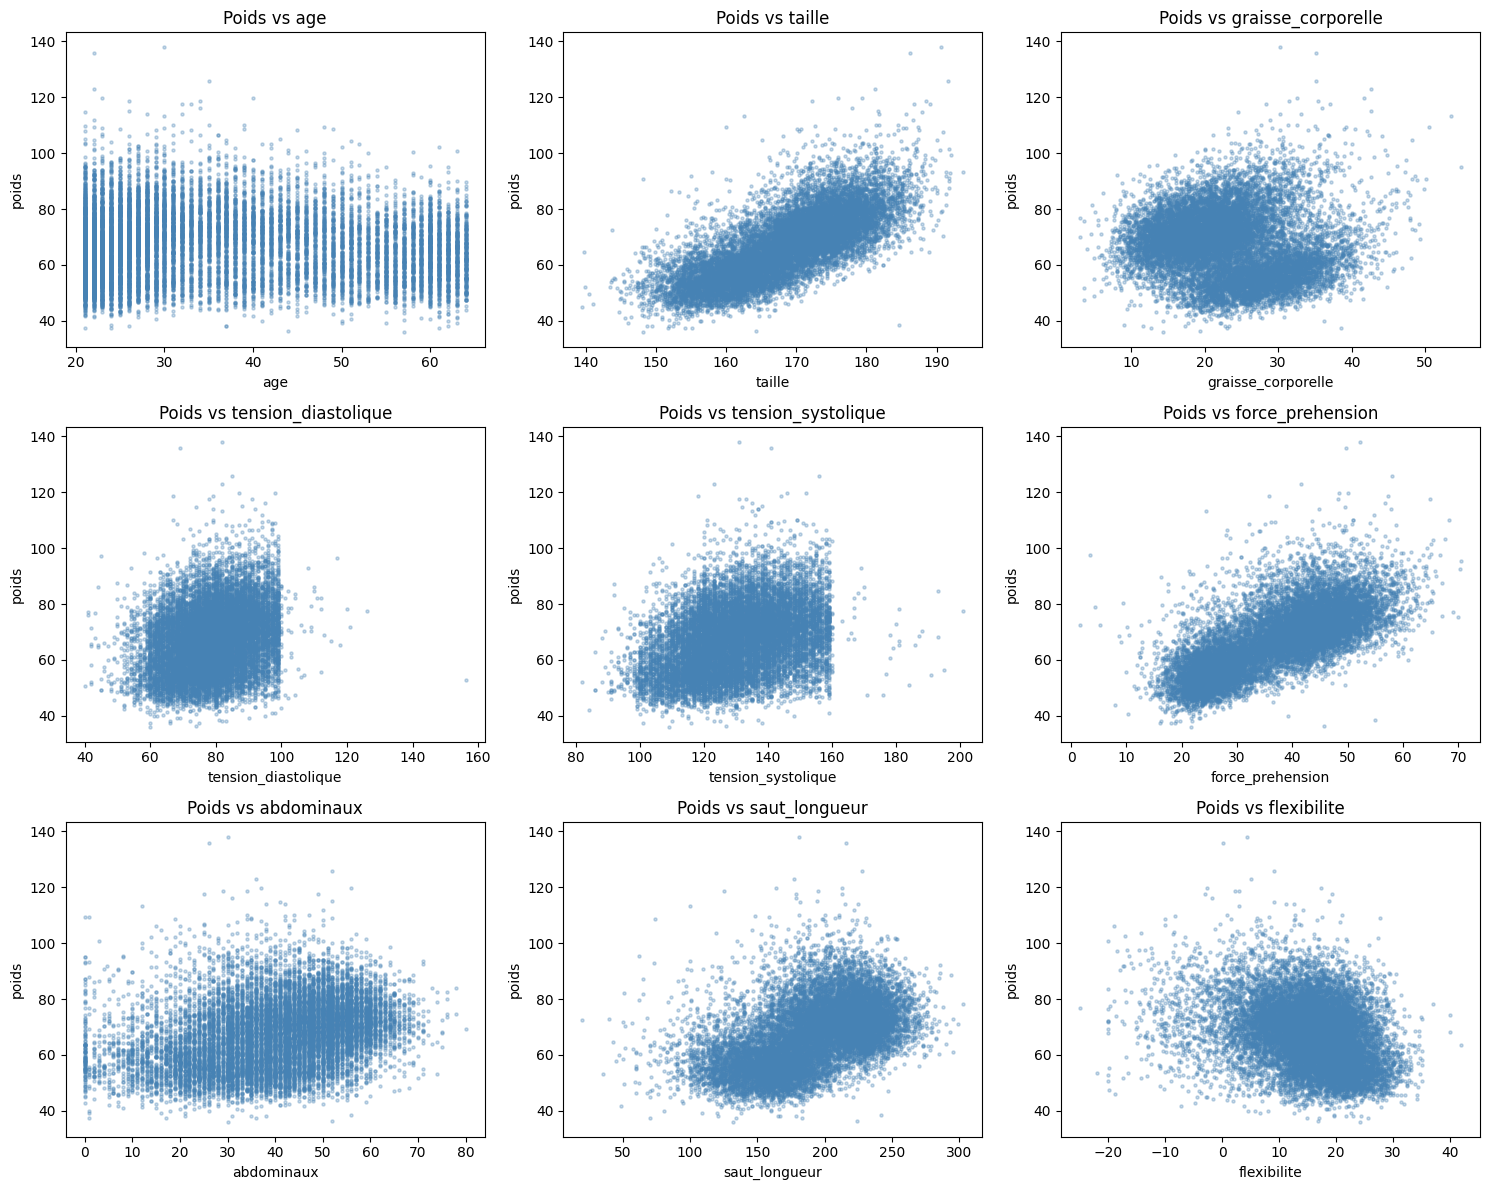

In [75]:
features = ['age', 'taille', 'graisse_corporelle', 'tension_diastolique',
            'tension_systolique', 'force_prehension', 'abdominaux',
            'saut_longueur', 'flexibilite']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['poids'], alpha=0.3, color='steelblue', s=5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('poids')
    axes[i].set_title(f'Poids vs {feature}')

plt.tight_layout()
plt.show()

## 📊 Résumé — Visualisation Poids vs Features

Après analyse visuelle des scatter plots, voici ce qu'on observe :

**Relations fortes :**
- `taille_cm` → relation linéaire claire et forte ✅
- `force_prehension` → tendance positive modérée ✅

**Relations modérées :**
- `graisse_corporelle` → relation existe mais non linéaire ⚠️
- `saut_longueur` → légère tendance positive ⚠️

**Relations faibles :**
- `age` → nuage dispersé, pas de tendance claire 😐
- `tension_diastolique` → pas de relation linéaire 😐
- `tension_systolique` → pas de relation linéaire 😐
- `abdominaux` → relation très faible 😐
- `flexibilite_cm` → pas de relation claire 😐

**Conclusion :**
La taille est visuellement le meilleur prédicteur du poids dans ce dataset.
On confirmera ces observations avec la matrice de corrélation.

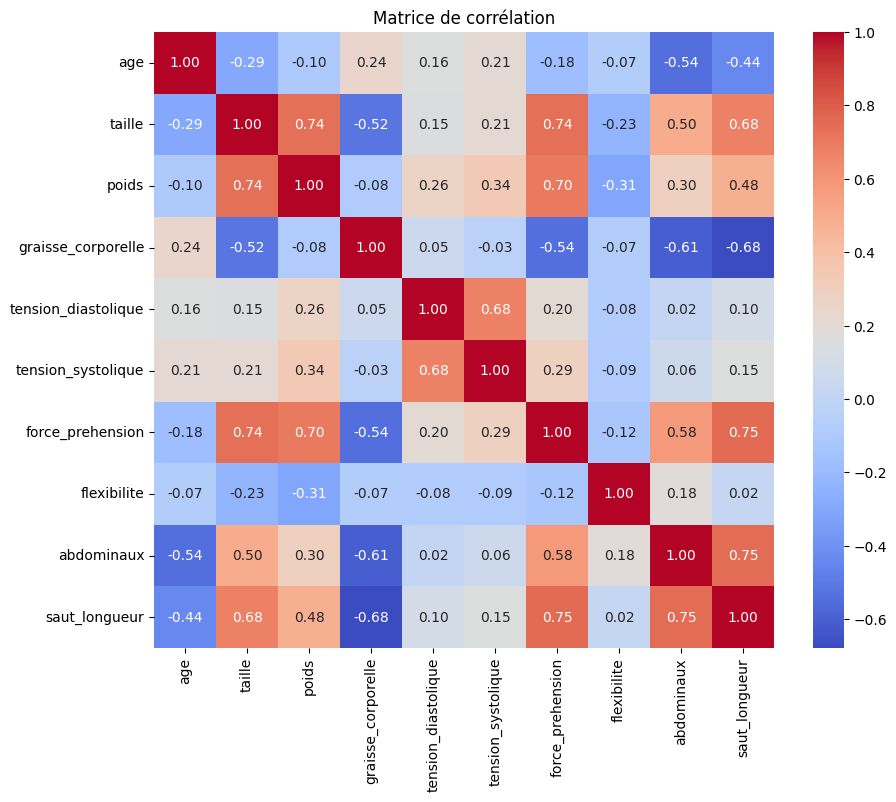

In [77]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

## 📊 Résumé — Matrice de corrélation

La matrice de corrélation mesure l'influence de chaque feature sur le poids (valeur de -1 à +1).

**Meilleurs prédicteurs du poids :**
- `taille` → 0.74 : plus le patient est grand, plus il est lourd ✅
- `force_prehension` → 0.70 : plus de muscle = plus de force et plus de poids ✅
- `saut_longueur` → 0.48 : relation modérée ⚠️

**Prédicteurs faibles :**
- `tension_systolique` → 0.34 ⚠️
- `abdominaux` → 0.30 ⚠️
- `flexibilite` → -0.31 (relation inverse légère) ⚠️

**Prédicteurs quasi nuls :**
- `graisse_corporelle` → -0.08 😐
- `tension_diastolique` → 0.26 😐
- `age` → -0.10 😐

**Conclusion :**
La taille et la force de préhension sont les deux variables
les plus corrélées avec le poids. Le modèle Linear Regression
va principalement s'appuyer sur ces deux features.

## Preparation des données et Préprocessing


In [78]:
from sklearn.model_selection import train_test_split

# Définir X et y
X = df.drop(columns=['poids'])
y = df['poids']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (10683, 9)
X_test  : (2671, 9)
y_train : (10683,)
y_test  : (2671,)


In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Normalisation effectuée !")

Normalisation effectuée !


In [81]:
import joblib

joblib.dump(scaler, 'scaler_j1.pkl')
print("Scaler sauvegardé !")

Scaler sauvegardé !


# Entrainement du modele

In [85]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(" Modèle entraîné !")

 Modèle entraîné !


In [88]:
model.score(X_test_scaled, y_test)

0.7931856092342219

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 4.18
RMSE : 5.44
R²   : 0.7932


## **NOTE GENERALE :** Voici comment nous pouvons evaluer le modele pour quelqu'un qui ne faire pas du marchine learning !

---


1. **MAE = 4.18**

En moyenne le modèle se trompe de ±4.18 kg sur le poids prédit. Ni plus ni moins — c'est une erreur moyenne.

2. **RMSE = 5.44**

Les erreurs les plus grandes atteignent ±5.44 kg — le RMSE pénalise plus les grosses erreurs.

3. **R² = 0.7932**

Le modèle explique 79.32% de la variance du poids. ✅

**EXEMPLE :** Concrètement en clinique :
Si un patient pèse réellement 70 kg, ton modèle peut prédire entre 65.82 kg et 74.18 kg.


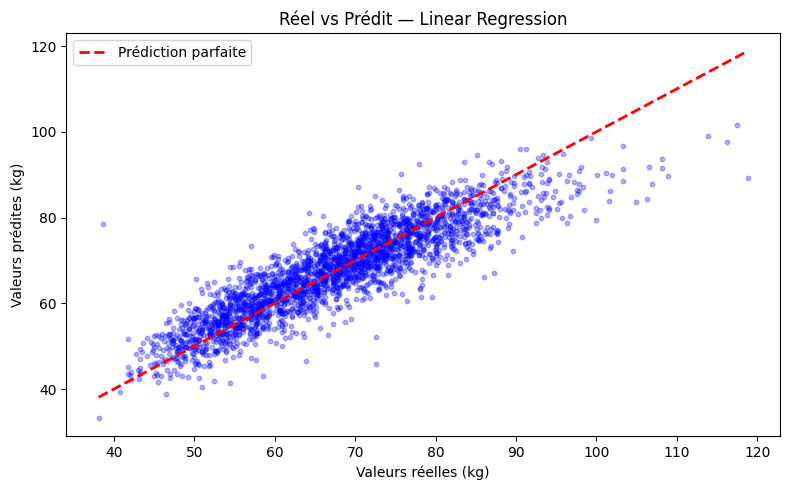

In [96]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Prédiction parfaite')

plt.xlabel("Valeurs réelles (kg)")
plt.ylabel("Valeurs prédites (kg)")
plt.title("Réel vs Prédit — Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

## Test rapide : Nous allons supprilmer quelques features et reentrainer le modele pour voir ce que ca va donner

In [94]:
# Supprimer les features faibles
X_reduit = df.drop(columns=['poids', 'age', 'graisse_corporelle', 'tension_diastolique'])
y = df['poids']

# Réentraîner
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduit, y, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

model_r = LinearRegression()
model_r.fit(X_train_r_scaled, y_train_r)

r2_r = r2_score(y_test_r, model_r.predict(X_test_r_scaled))
print(f"R² avec toutes les features : 0.7932")
print(f"R² sans features faibles    : {r2_r:.4f}")

R² avec toutes les features : 0.7932
R² sans features faibles    : 0.6536


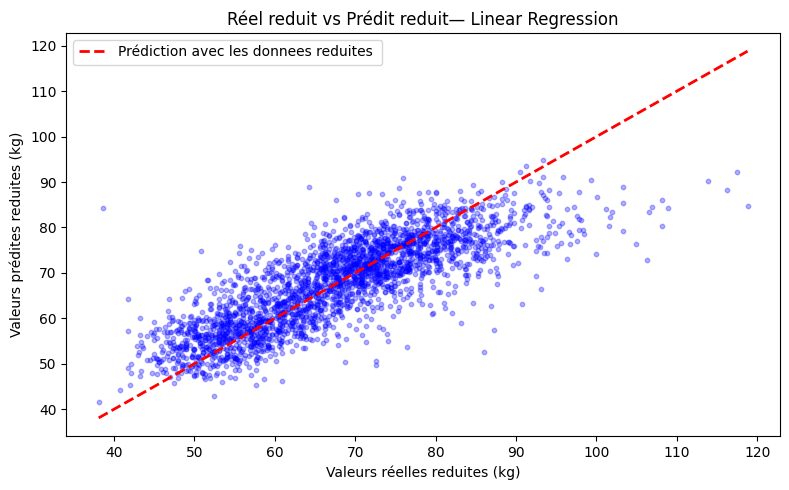

In [99]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_r, model_r.predict(X_test_r_scaled), alpha=0.3, color='blue', s=10)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', linewidth=2, label='Prédiction avec les donnees reduites ')

plt.xlabel("Valeurs réelles reduites (kg)")
plt.ylabel("Valeurs prédites reduites (kg)")
plt.title("Réel reduit vs Prédit reduit— Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()